# Traditional Feature Cache

This notebook loads the combined HOG and RGB colour feature files created by `features.ipynb`.

It does not extract the features again. It loads the saved train, validation, and test features and prepares them for `traditional_classifier.ipynb`.

The feature files are stored locally in:

```text
outputs/traditional_features/

## 1. Import libraries

Import the libraries needed to locate and load the cached feature files.

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## 2. Find the project root

The notebook is stored inside `src/traditional/features/`.

This cell searches upward until it finds the main project folder containing `src`, `outputs`, and `.gitignore`.

In [7]:
current_path = Path.cwd().resolve()

for candidate in [current_path, *current_path.parents]:
    if (
        (candidate / "src").exists()
        and (candidate / ".gitignore").exists()
    ):
        project_root = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the project root."
    )

print("Project root:", project_root)

Project root: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group


## 3. Set the feature cache directory

The generated feature files are stored in `outputs/traditional_features/`.

The `outputs` folder is ignored by Git, so the feature files are shared separately through OneDrive.

In [8]:
FEATURE_CACHE_DIR = (
    project_root
    / "outputs"
    / "traditional_features"
)

print(
    "Feature cache directory:",
    FEATURE_CACHE_DIR
)

Feature cache directory: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\outputs\traditional_features


## 4. Download the feature files

The generated feature files are shared through OneDrive because the `outputs` folder is not tracked by Git.

Download the files from:

[Traditional feature files on OneDrive](https://unsw-my.sharepoint.com/:f:/g/personal/z5528581_ad_unsw_edu_au/IgAsAxZV1fJQSbL1AAmSgGoaAU-ZRhVTJmVLsHFxH7leipA?e=beAfW7)

After downloading, place the files in:

```text
outputs/traditional_features/

## 5. Define the expected cache files

Set the expected filenames for the train, validation, and test feature files.

In [9]:
CACHE_FILES = {
    "train": (
        FEATURE_CACHE_DIR
        / "train_combined_features.npz"
    ),

    "validation": (
        FEATURE_CACHE_DIR
        / "validation_combined_features.npz"
    ),

    "test": (
        FEATURE_CACHE_DIR
        / "test_combined_features.npz"
    )
}

for split_name, cache_path in CACHE_FILES.items():
    print(
        f"{split_name}: {cache_path}"
    )

train: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\outputs\traditional_features\train_combined_features.npz
validation: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\outputs\traditional_features\validation_combined_features.npz
test: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\outputs\traditional_features\test_combined_features.npz


## 6. Check the downloaded files

Check whether the three required feature files are available in the local output folder.

In [10]:
missing_files = []

for split_name, cache_path in CACHE_FILES.items():
    if cache_path.exists():
        file_size_mb = (
            cache_path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"{split_name}: Found "
            f"({file_size_mb:.2f} MB)"
        )

    else:
        print(
            f"{split_name}: Missing"
        )

        missing_files.append(
            cache_path.name
        )

if missing_files:
    print("\nMissing files:")

    for file_name in missing_files:
        print("-", file_name)

    print(
        "\nDownload them from OneDrive and place "
        "them in:"
    )

    print(FEATURE_CACHE_DIR)

train: Found (370.90 MB)
validation: Found (92.73 MB)
test: Found (92.70 MB)


## 7. Define the cache loading function

This function loads one dataset split from its `.npz` file.

It returns:

- the feature matrix
- the labels
- the image paths

The returned values match the inputs used by `traditional_classifier.ipynb`.

In [11]:
def load_cached_features(split_name):
    if split_name not in CACHE_FILES:
        raise ValueError(
            f"split_name must be one of "
            f"{sorted(CACHE_FILES.keys())}"
        )

    cache_path = CACHE_FILES[split_name]

    if not cache_path.exists():
        raise FileNotFoundError(
            f"Feature file was not found: "
            f"{cache_path}\n"
            f"Download it from OneDrive and place "
            f"it in outputs/traditional_features/."
        )

    with np.load(
        cache_path,
        allow_pickle=True
    ) as data:
        features = data["features"]
        labels = data["labels"]
        file_paths = data["file_paths"]

    return features, labels, file_paths

## 8. Load the training cache

Load the training features, labels, and image paths.

In [12]:
X_train, y_train, train_paths = (
    load_cached_features("train")
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("train_paths shape:", train_paths.shape)
print("X_train dtype:", X_train.dtype)

X_train shape: (20000, 6180)
y_train shape: (20000,)
train_paths shape: (20000,)
X_train dtype: float32


## 9. Load the validation cache

Load the validation features, labels, and image paths.

The variable names use `val` to match `traditional_classifier.ipynb`.

In [13]:
X_val, y_val, val_paths = (
    load_cached_features("validation")
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("val_paths shape:", val_paths.shape)
print("X_val dtype:", X_val.dtype)

X_val shape: (5000, 6180)
y_val shape: (5000,)
val_paths shape: (5000,)
X_val dtype: float32


## 10. Load the test cache

Load the test features, labels, and image paths.

In [14]:
X_test, y_test, test_paths = (
    load_cached_features("test")
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("test_paths shape:", test_paths.shape)
print("X_test dtype:", X_test.dtype)

X_test shape: (5000, 6180)
y_test shape: (5000,)
test_paths shape: (5000,)
X_test dtype: float32


## 11. Show the loaded cache summary

Display a short summary of the loaded train, validation, and test data.

In [15]:
cached_splits = {
    "train": (
        X_train,
        y_train,
        train_paths
    ),

    "validation": (
        X_val,
        y_val,
        val_paths
    ),

    "test": (
        X_test,
        y_test,
        test_paths
    )
}

for split_name, values in cached_splits.items():
    features, labels, paths = values

    print(split_name)
    print("Feature shape:", features.shape)
    print("Label shape:", labels.shape)
    print("Path shape:", paths.shape)
    print("Feature dtype:", features.dtype)
    print()

train
Feature shape: (20000, 6180)
Label shape: (20000,)
Path shape: (20000,)
Feature dtype: float32

validation
Feature shape: (5000, 6180)
Label shape: (5000,)
Path shape: (5000,)
Feature dtype: float32

test
Feature shape: (5000, 6180)
Label shape: (5000,)
Path shape: (5000,)
Feature dtype: float32



## 12. Prepare the classifier inputs

Store the loaded arrays using the variable names expected by `traditional_classifier.ipynb`.

In [16]:
classifier_inputs = {
    "X_train": X_train,
    "y_train": y_train,
    "train_paths": train_paths,

    "X_val": X_val,
    "y_val": y_val,
    "val_paths": val_paths,

    "X_test": X_test,
    "y_test": y_test,
    "test_paths": test_paths
}

for variable_name, value in classifier_inputs.items():
    print(
        f"{variable_name}: {value.shape}"
    )

X_train: (20000, 6180)
y_train: (20000,)
train_paths: (20000,)
X_val: (5000, 6180)
y_val: (5000,)
val_paths: (5000,)
X_test: (5000, 6180)
y_test: (5000,)
test_paths: (5000,)


## 13. Visualise the dataset sizes

Compare the number of cached samples in the training, validation, and test datasets.

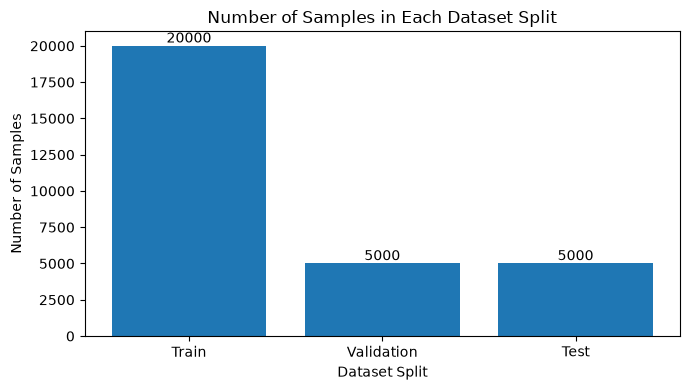

In [19]:
split_names = [
    "Train",
    "Validation",
    "Test"
]

sample_counts = [
    len(X_train),
    len(X_val),
    len(X_test)
]

plt.figure(figsize=(7, 4))
plt.bar(
    split_names,
    sample_counts
)

plt.title(
    "Number of Samples in Each Dataset Split"
)

plt.xlabel(
    "Dataset Split"
)

plt.ylabel(
    "Number of Samples"
)

for index, count in enumerate(sample_counts):
    plt.text(
        index,
        count,
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 14. Visualise one cached feature vector

Display the first values from one training feature vector.

The combined feature contains HOG values followed by RGB colour histogram values.

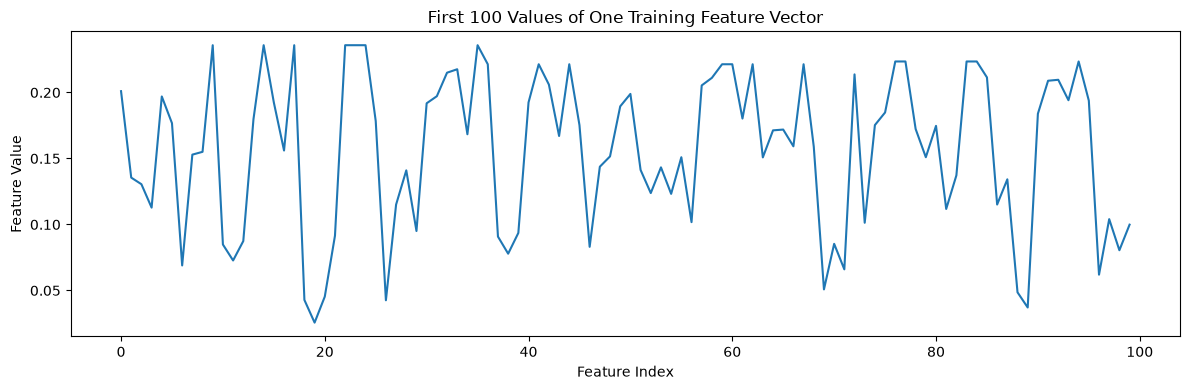

Sample label: 364
Full feature shape: (6180,)
Image path: train_mini/07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii/f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg


In [20]:
sample_index = 0
display_length = 100

sample_feature = X_train[
    sample_index,
    :display_length
]

plt.figure(figsize=(12, 4))

plt.plot(
    range(display_length),
    sample_feature
)

plt.title(
    "First 100 Values of One Training Feature Vector"
)

plt.xlabel(
    "Feature Index"
)

plt.ylabel(
    "Feature Value"
)

plt.tight_layout()
plt.show()

print(
    "Sample label:",
    y_train[sample_index]
)

print(
    "Full feature shape:",
    X_train[sample_index].shape
)

print(
    "Image path:",
    train_paths[sample_index]
)

## 15. Visualise the HOG and colour feature boundary

Display the end of the HOG section and the complete RGB colour histogram section from one cached feature vector.

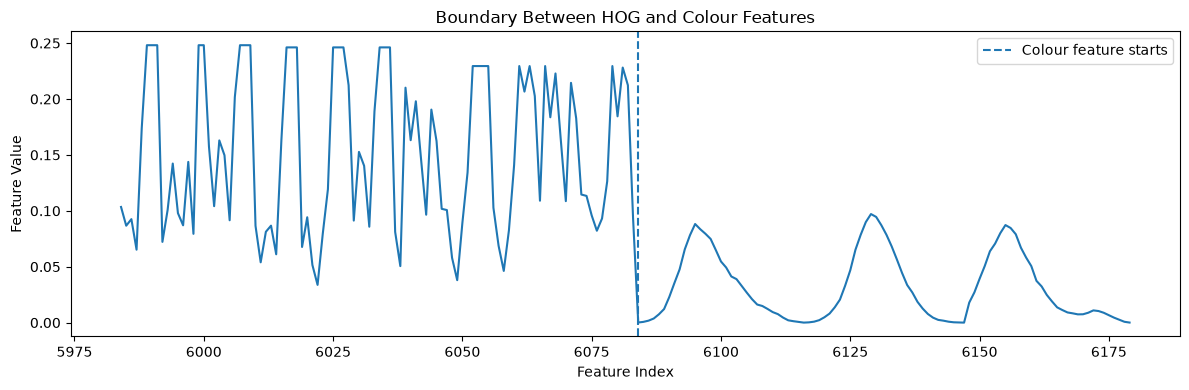

In [21]:
sample_index = 0

boundary_start = 5984
boundary_end = 6180

boundary_feature = X_train[
    sample_index,
    boundary_start:boundary_end
]

feature_indices = range(
    boundary_start,
    boundary_end
)

plt.figure(figsize=(12, 4))

plt.plot(
    feature_indices,
    boundary_feature
)

plt.axvline(
    x=6084,
    linestyle="--",
    label="Colour feature starts"
)

plt.title(
    "Boundary Between HOG and Colour Features"
)

plt.xlabel(
    "Feature Index"
)

plt.ylabel(
    "Feature Value"
)

plt.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook loads the combined HOG and RGB colour feature files created by `features.ipynb`.

The files are loaded from:

```text
outputs/traditional_features/